## MamaDey AI - XGBoost, SHAP, & Final Evaluation

**Input:** 
- `models/logistic_regression.pkl`
- `models/random_forest.pkl`
- train/test CSVs

**Output**
- `models/xgboost.pkl`
- `outputs/final_evaluation_report.csv`

### Architecture

- XGBoostTrainer      -> trains XBoost with GridSearchCV
- FinalEvaluator      -> three-way comparison: lR vs RF vs XGBoost
- SHAPAnalyser        -> SHAP values for interpretability
- FinalModelSelector  -> selects best model, produces dissertation table
- ReportGenerator     -> structured findings report saved as .md

**Week 6-7 baseline to beat**
- Logistic Regression AUC-ROC: 0.8096
- Random Forest AUC-ROC: 0.8438

### 1. Imports & Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, logging, warnings, pickle
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score,
                              brier_score_loss, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
%pip -q install shap

try:
    import shap
    SHAP_available = True
    print("SHAP available.")
except ImportError:
    SHAP_available = False
    print("SHAP not installed. Run: pip install shap")
    print("All other analysis will run normally.")

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

logging.basicConfig(level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("MamaDeyAI")

processed_dir   = "../data/processed/"
models_dir      = "../models/"
output_dir      = "../outputs/"
random_state    = 42        # for reproduceability

os.makedirs(models_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
log.info("Environment is ready.")

15:53:09 [INFO] Environment is ready.


Note: you may need to restart the kernel to use updated packages.
SHAP available.


### 2. Load Data & Trained Models

In [3]:
X_train = pd.read_csv(f"{processed_dir}X_train.csv")
X_test  = pd.read_csv(f"{processed_dir}X_test.csv")
y_train = pd.read_csv(f"{processed_dir}y_train.csv").squeeze()
y_test  = pd.read_csv(f"{processed_dir}y_test.csv").squeeze()

with open(f"{processed_dir}feature_cols.json") as f:
    feature_columns = json.load(f)

X_train = X_train[[c for c in feature_columns if c in X_train.columns]]
X_test  = X_test[[c  for c in feature_columns if c in X_test.columns]]

with open(f"{models_dir}logistic_regression.pkl", "rb") as f:
    lr_model = pickle.load(f)
with open(f"{models_dir}random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

# SMOTE for XGBoost training
smote = SMOTE(sampling_strategy=0.3, random_state=random_state, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Scaler for LR predictions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = round(neg / pos, 2)

log.info(f"Train: {X_train.shape} | Test: {X_test.shape}")
log.info(f"scale_pos_weight: {scale_pos_weight}")
log.info(f"LR loaded: {type(lr_model).__name__}")
log.info(f"RF loaded: {type(rf_model).__name__}")

15:53:16 [INFO] Train: (2690, 30) | Test: (673, 30)
15:53:16 [INFO] scale_pos_weight: 14.55
15:53:16 [INFO] LR loaded: LogisticRegression
15:53:16 [INFO] RF loaded: RandomForestClassifier


### 3. XGBoostTrainer

In [4]:
# Create a class that trains XGBoost with GridSearchCV
class XGBoostTrainer:
    """
    Compares two imbalance strategies and keeps the better performer:
    1. SMOTE-balanced data (consistent with baseline RF approach)
    2. scale_pos_weight on original imbalanced data
    """

    cv_folds = 5

    XGB_param_grid = {
        "n_estimators":     [100, 200, 300],
        "max_depth":        [3, 4, 6],
        "learning_rate":    [0.01, 0.05, 0.1],
        "subsample":        [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 5],
    }

    def __init__(self, scale_pos_weight, random_state=42):
        self.spw          = scale_pos_weight
        self.random_state = random_state
        self.cv           = StratifiedKFold(
            n_splits=self.cv_folds, shuffle=True,
            random_state=random_state
        )
        self.model        = None
        self.cv_scores    = None
        self.best_params  = None
        self.winning_strategy = None

    def train(self, X_train_bal, y_train_bal, X_train_orig, y_train_orig):
        n_combos = 1
        for v in self.XGB_param_grid.values():
            n_combos *= len(v)
        log.info(f"XGBoost GridSearchCV: {n_combos} combinations x2 strategies x{self.cv_folds} folds")
        log.info("This may take 5-10 minutes...")

        # Strategy 1: SMOTE
        xgb1 = XGBClassifier(random_state=self.random_state,
                              eval_metric="logloss", verbosity=0)
        grid1 = GridSearchCV(xgb1, self.XGB_param_grid,
                             cv=self.cv, scoring="roc_auc",
                             n_jobs=-1, verbose=0)
        grid1.fit(X_train_bal, y_train_bal)

        # Strategy 2: scale_pos_weight
        xgb2 = XGBClassifier(scale_pos_weight=self.spw,
                              random_state=self.random_state,
                              eval_metric="logloss", verbosity=0)
        grid2 = GridSearchCV(xgb2, self.XGB_param_grid,
                             cv=self.cv, scoring="roc_auc",
                             n_jobs=-1, verbose=0)
        grid2.fit(X_train_orig, y_train_orig)

        # Keep best
        if grid1.best_score_ >= grid2.best_score_:
            self.model            = grid1.best_estimator_
            self.best_params      = grid1.best_params_
            self.winning_strategy = "SMOTE-balanced"
            X_cv, y_cv            = X_train_bal, y_train_bal
        else:
            self.model            = grid2.best_estimator_
            self.best_params      = grid2.best_params_
            self.winning_strategy = "scale_pos_weight"
            X_cv, y_cv            = X_train_orig, y_train_orig

        self.cv_scores = cross_val_score(
            self.model, X_cv, y_cv, cv=self.cv, scoring="roc_auc"
        )
        log.info(f"Winner: {self.winning_strategy}")
        log.info(f"Best params: {self.best_params}")
        log.info(f"CV AUC-ROC: {self.cv_scores.mean():.4f} (+/- {self.cv_scores.std():.4f})")
        return self

    def save(self, models_dir):
        path = f"{models_dir}xgboost.pkl"
        with open(path, "wb") as f:
            pickle.dump(self.model, f)
        log.info(f"XGBoost saved -> {path}")

### 4. FinalEvaluator

In [5]:
# Create a class that does a 3-way comparison of all models on the test set held-out.

class FinalEvaluator:
    """
    Threshold selection enforces minimum sensitivity of 0.60
    then maximises F1 — clinically motivated.
    """

    colours = {
        "Logistic Regression": "#534AB7",
        "Random Forest":       "#1D9E75",
        "XGBoost":             "#BA7517",
    }

    def __init__(self, y_test, outputs_dir="../outputs/"):
        self.y_test      = y_test
        self.outputs_dir = outputs_dir
        self.results     = {}

    def evaluate(self, name, model, X_test, cv_scores=None):
        y_prob = model.predict_proba(X_test)[:, 1]
        thresholds = np.arange(0.05, 0.80, 0.01)

        best_f1, best_t = 0, 0.5
        for t in thresholds:
            yp = (y_prob >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(self.y_test, yp, labels=[0,1]).ravel()
            sens = tp / max(tp + fn, 1)
            f1   = f1_score(self.y_test, yp, zero_division=0)
            if sens >= 0.60 and f1 > best_f1:
                best_f1, best_t = f1, t

        y_pred = (y_prob >= best_t).astype(int)
        tn, fp, fn, tp = confusion_matrix(self.y_test, y_pred, labels=[0,1]).ravel()

        self.results[name] = {
            "AUC-ROC":     round(roc_auc_score(self.y_test, y_prob), 4),
            "Sensitivity": round(tp / max(tp+fn, 1), 4),
            "Specificity": round(tn / max(tn+fp, 1), 4),
            "Precision":   round(precision_score(self.y_test, y_pred, zero_division=0), 4),
            "F1-Score":    round(f1_score(self.y_test, y_pred, zero_division=0), 4),
            "Brier Score": round(brier_score_loss(self.y_test, y_prob), 4),
            "Threshold":   round(best_t, 2),
            "CV AUC Mean": round(cv_scores.mean(), 4) if cv_scores is not None else None,
            "CV AUC Std":  round(cv_scores.std(),  4) if cv_scores is not None else None,
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "y_prob": y_prob,
        }
        log.info(f"{name:22s} AUC={self.results[name]["AUC-ROC"]:.4f} "
                 f"Sens={self.results[name]["Sensitivity"]:.4f} "
                 f"F1={self.results[name]["F1-Score"]:.4f}")
        
    def plot_roc(self):
        fig, ax = plt.subplots(figsize=(8, 6))
        for name, res in self.results.items():
            fpr, tpr, _ = roc_curve(self.y_test, res["y_prob"])
            ax.plot(fpr, tpr, lw=2.5, color=self.colours.get(name, "gray"),
                    label=f"{name} (AUC = {res["AUC-ROC"]:.3f})")
        ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random chance")
        ax.axhline(0.80, color="#BC1111", ls=":", lw=1.5, alpha=0.7,
                   label="Target (AUC=0.80)")
        ax.set_xlabel("False Positive Rate (1 - Specificity)")
        ax.set_ylabel("True Positive Rate (Sensitivity)")
        ax.set_title("ROC Curves -- MamaDey AI Three-Model Comparison",
                     fontweight="bold")
        ax.legend(loc="lower right", fontsize=10)
        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        plt.tight_layout()
        fig.savefig(f"{self.outputs_dir}figure11_final_roc_comparison.png",
                    bbox_inches="tight", dpi=150)
        plt.show(); plt.close(fig)
        log.info("Saved figure11_final_roc_comparison.png")

    def plot_metrics_comparison(self):
        metrics = ["AUC-ROC","Sensitivity","Specificity","F1-Score"]
        models  = list(self.results.keys())
        x       = np.arange(len(metrics))
        width   = 0.25
        fig, ax = plt.subplots(figsize=(11, 5))
        for i, model in enumerate(models):
            vals = [self.results[model][m] for m in metrics]
            bars = ax.bar(x + i*width, vals, width,
                          label=model,
                          color=self.colours.get(model, "gray"),
                          edgecolor="white", alpha=0.85)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.008,
                        f"{val:.3f}", ha="center", fontsize=8.5)
        ax.axhline(0.80, color="#E24B4A", ls=":", lw=1.5,
                   alpha=0.7, label="Target (0.80)")
        ax.set_xticks(x + width)
        ax.set_xticklabels(metrics)
        ax.set_ylim([0, 1.12])
        ax.set_ylabel("Score")
        ax.set_title("Model Performance Comparison -- Test Set Metrics",
                     fontweight="bold")
        ax.legend()
        plt.tight_layout()
        fig.savefig(f"{self.outputs_dir}figure12_metrics_comparison.png",
                    bbox_inches="tight", dpi=150)
        plt.show(); plt.close(fig)
        log.info("Saved figure12_metrics_comparison.png")

    def plot_confusion_matrices(self):
        n = len(self.results)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
        if n == 1: axes = [axes]
        for ax, (name, res) in zip(axes, self.results.items()):
            y_pred = (res["y_prob"] >= res["Threshold"]).astype(int)
            cm     = confusion_matrix(self.y_test, y_pred)
            disp   = ConfusionMatrixDisplay(cm, display_labels=["No adverse","Adverse"])
            disp.plot(ax=ax, colorbar=False, cmap="Blues")
            ax.set_title(f"{name}\nAUC={res["AUC-ROC"]:.3f}  "
                         f"Sens={res["Sensitivity"]:.3f}")
        plt.suptitle("Confusion Matrices -- Held-Out Test Set",
                     fontweight="bold", y=1.02)
        plt.tight_layout()
        fig.savefig(f"{self.outputs_dir}figure13_confusion_matrices.png",
                    bbox_inches="tight", dpi=150)
        plt.show(); plt.close(fig)
        log.info("Saved figure13_confusion_matrices.png")

    def plot_threshold_tradeoff(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        thresholds = np.arange(0.05, 0.80, 0.01)
        for name, res in self.results.items():
            sens_list, spec_list = [], []
            for t in thresholds:
                yp = (res["y_prob"] >= t).astype(int)
                tn, fp, fn, tp = confusion_matrix(
                    self.y_test, yp, labels=[0,1]).ravel()
                sens_list.append(tp / max(tp+fn, 1))
                spec_list.append(tn / max(tn+fp, 1))
            c = self.colours.get(name, "gray")
            ax.plot(thresholds, sens_list, lw=2, color=c,
                    label=f"{name} Sensitivity")
            ax.plot(thresholds, spec_list, lw=1.5, ls="--",
                    color=c, alpha=0.6, label=f"{name} Specificity")
        ax.axhline(0.60, color="#F02020", ls=":", lw=1,
                   label="Min sensitivity target (0.60)")
        ax.set_xlabel("Classification Threshold")
        ax.set_ylabel("Score")
        ax.set_title("Sensitivity vs Specificity Trade-off by Threshold",
                     fontweight="bold")
        ax.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        fig.savefig(f"{self.outputs_dir}figure14_threshold_tradeoff.png",
                    bbox_inches="tight", dpi=150)
        plt.show(); plt.close(fig)
        log.info("Saved figure14_threshold_tradeoff.png")

    def plot_all(self):
        self.plot_roc()
        self.plot_metrics_comparison()
        self.plot_confusion_matrices()
        self.plot_threshold_tradeoff()

    def print_table(self):
        cols = ["AUC-ROC","Sensitivity","Specificity","Precision",
                "F1-Score","Brier Score","CV AUC Mean","Threshold"]
        rows = []
        for name, res in self.results.items():
            row = {"Model": name}
            row.update({c: res[c] for c in cols})
            rows.append(row)
        table = pd.DataFrame(rows).set_index("Model")
        print()
        print("-" * 70)
        print("FINAL MODEL COMPARISON (HELD-OUT TEST SET)")
        print("-" * 70)
        print(table.to_string())
        print("-" * 70)
        print()
        for name, res in self.results.items():
            met  = res["AUC-ROC"] >= 0.80
            icon = chr(10003) if met else chr(10007)
            print(f"  {icon}  {name}: AUC-ROC={res["AUC-ROC"]:.4f}  "
                  f"Sensitivity={res["Sensitivity"]:.4f}")
        return table

    def save_report(self, path):
        cols = ["AUC-ROC","Sensitivity","Specificity","Precision",
                "F1-Score","Brier Score","Threshold",
                "CV AUC Mean","CV AUC Std","TP","FP","TN","FN"]
        rows = []
        for name, res in self.results.items():
            row = {"Model": name}
            row.update({c: res[c] for c in cols})
            rows.append(row)
        pd.DataFrame(rows).to_csv(path, index=False)
        log.info(f"Final report saved -> {path}")

    

### 5. SHAPAnalyser

In [6]:
# create a class for SHAP interpretability (RF and XGBoost)
class SHAPAnalyser:
    """
    Uses TreeExplainer - fast and exact for tree-based models.
    Saves summary plot and mean absolute SHAP bar chart for each model.
    """

    def __init__(self, feature_columns, outputs_dir="../outputs/"):
        self.feature_columns = feature_columns
        self.outputs_dir  = outputs_dir

    def analyse(self, name, model, X_test):
        if not SHAP_available:
            log.warning('SHAP not available -- install with: pip install shap')
            return None

        log.info(f'Computing SHAP values for {name}...')
        X_arr = X_test.values if hasattr(X_test, 'values') else X_test
        fname = name.lower().replace(' ', '_')   # defined ONCE, at the top

        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_arr)

        if isinstance(shap_values, list):
            sv = shap_values[1]
        elif shap_values.ndim == 3:
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

        # Beeswarm summary
        plt.figure(figsize=(9, 6))
        shap.summary_plot(sv, X_arr, feature_names=self.feature_columns,
                        show=False, plot_size=None)
        plt.title(f'SHAP Summary -- {name}', fontweight='bold', pad=15)
        plt.tight_layout()
        plt.savefig(f'{self.outputs_dir}fig_shap_summary_{fname}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        plt.close()

        # Mean absolute SHAP bar chart
        mean_shap = pd.DataFrame({
            'feature':   self.feature_columns[:sv.shape[1]],
            'mean_shap': np.abs(sv).mean(axis=0)
        }).sort_values('mean_shap', ascending=True).tail(15)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(mean_shap['feature'], mean_shap['mean_shap'],
                color='#1D9E75', edgecolor='white')
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(f'Mean Absolute SHAP Values -- {name} (Top 15)',
                    fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{self.outputs_dir}fig_shap_bar_{fname}.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        plt.close(fig)

        mean_shap.sort_values('mean_shap', ascending=False).to_csv(
            f'{self.outputs_dir}shap_importance_{fname}.csv', index=False
        )
        log.info(f'SHAP analysis complete for {name}')
        return mean_shap

### 6. ReportGenerator (Week 8_10)

In [7]:
class ReportGenerator_Week_8_10:
    """
    Generates the Week 8 findings report.
    Reads from evaluator and xgb_trainer objects in memory.
    Saves to outputs/report_week_8_10.md
    """

    def __init__(self, evaluator, xgb_trainer, best_model_name,
                 y_test, outputs_dir="../outputs/"):
        self.evaluator       = evaluator
        self.xgb_trainer     = xgb_trainer
        self.best_model_name = best_model_name
        self.y_test          = y_test
        self.outputs_dir     = outputs_dir

    def generate(self):
        m      = self._compute_metrics()
        report = self._build_report(m)
        print(report)
        path = f"{self.outputs_dir}report_week8_10.md"
        with open(path, "w", encoding="utf-8") as f:
            f.write(report)
        log.info(f"Report saved -> {path}")
        return m

    def _compute_metrics(self):
        res = self.evaluator.results
        lr  = res.get("Logistic Regression", {})
        rf  = res.get("Random Forest", {})
        xgb = res.get("XGBoost", {})
        n   = len(self.y_test)
        npos = int(self.y_test.sum())
        return {
            "n_test": n, "n_test_pos": npos,
            "lr_auc":  lr.get("AUC-ROC"),  "lr_sens": lr.get("Sensitivity"),
            "lr_spec": lr.get("Specificity"), "lr_f1": lr.get("F1-Score"),
            "lr_brier": lr.get("Brier Score"), "lr_tp": lr.get("TP"),
            "lr_fn":  lr.get("FN"),
            "rf_auc":  rf.get("AUC-ROC"),  "rf_sens": rf.get("Sensitivity"),
            "rf_spec": rf.get("Specificity"), "rf_f1": rf.get("F1-Score"),
            "rf_brier": rf.get("Brier Score"), "rf_tp": rf.get("TP"),
            "rf_fn":  rf.get("FN"),
            "xgb_auc":  xgb.get("AUC-ROC"),  "xgb_sens": xgb.get("Sensitivity"),
            "xgb_spec": xgb.get("Specificity"), "xgb_f1": xgb.get("F1-Score"),
            "xgb_brier": xgb.get("Brier Score"), "xgb_tp": xgb.get("TP"),
            "xgb_fn": xgb.get("FN"),
            "xgb_cv_mean": xgb.get("CV AUC Mean"),
            "xgb_strategy": getattr(self.xgb_trainer, "winning_strategy", "N/A"),
            "best_model": self.best_model_name,
            "best_auc": res.get(self.best_model_name, {}).get("AUC-ROC"),
            "best_sens": res.get(self.best_model_name, {}).get("Sensitivity"),
        }

    def _build_report(self, m):
        def tick(val): return "MEETS target" if val and val >= 0.80 else "Below target"
        return f"""# MamaDey AI Findings Report (Week 8-10)
**Stage:** XGBoost Training, Three-Model Comparison, SHAP Interpretability
**Test set:** {m["n_test"]:,} records ({m["n_test_pos"]} adverse cases)

---

## 1. What Was Done

An XGBoost classifier was trained with GridSearchCV, comparing two class imbalance
strategies: SMOTE-balanced training data (consistent with the Random Forest approach)
and native scale_pos_weight handling on the original imbalanced data. The winning
strategy was {m["xgb_strategy"]}. All three models were evaluated on the held-out test
set using a clinically motivated threshold that enforces a minimum sensitivity of 0.60
before maximising F1. SHAP interpretability analysis was conducted on the two tree-based
models to identify the features driving predictions.

---

## 2. Key Findings

| Model               | AUC-ROC       | Sensitivity    | Specificity    | F1           | Brier           | Target              |
|---------------------|---------------|----------------|----------------|--------------|-----------------|---------------------|
| Logistic Regression | {m["lr_auc"]} | {m["lr_sens"]} | {m["lr_spec"]} | {m["lr_f1"]} | {m["lr_brier"]} | {tick(m["lr_auc"])} |
| Random Forest       | {m["rf_auc"]} | {m["rf_sens"]} | {m["rf_spec"]} | {m["rf_f1"]} | {m["rf_brier"]} | {tick(m["rf_auc"])} |
| XGBoost             | {m["xgb_auc"]}| {m["xgb_sens"]}| {m["xgb_spec"]}| {m["xgb_f1"]}| {m["xgb_brier"]}| {tick(m["xgb_auc"])}|

**Selected model: {m["best_model"]}**
- AUC-ROC: {m["best_auc"]}
- Sensitivity: {m["best_sens"]}

---

## 3. Dissertation-Ready Narrative

### 3.1 XGBoost Performance
The XGBoost classifier, trained using {m["xgb_strategy"]} with GridSearchCV optimisation,
achieved a test set AUC-ROC of {m["xgb_auc"]} and a sensitivity of {m["xgb_sens"]} on the
held-out test set of {m["n_test"]:,} records. Of the {m["n_test_pos"]} adverse outcome cases
in the test set, the model correctly identified {m["xgb_tp"]}, with {m["xgb_fn"]} cases
missed. The Brier Score of {m["xgb_brier"]} indicates model calibration comparable to
the other approaches.

### 3.2 Three-Model Comparison
All three models exceeded the dissertation target AUC-ROC of 0.80 on the held-out test set,
providing strong empirical support for the feasibility of machine learning-based maternal
risk prediction using the feature set developed from NDHS 2018 data. The Logistic Regression
baseline achieved an AUC-ROC of {m["lr_auc"]}, confirming genuine linear predictive signal
in the feature set. The Random Forest achieved {m["rf_auc"]} and XGBoost achieved {m["xgb_auc"]},
with the ensemble methods demonstrating superior discriminative performance over the linear
baseline. This pattern is consistent with findings reported by Ghosh et al. (2021) and
Ogunleye et al. (2023), who similarly found tree-based ensemble methods outperforming
logistic regression for maternal risk classification tasks.

### 3.3 Final Model Selection
The {m["best_model"]} was selected as the recommended model for the MamaDey AI framework
on the basis of achieving the highest AUC-ROC of {m["best_auc"]} among models meeting
the 0.80 dissertation target, with a sensitivity of {m["best_sens"]}, maximising the
detection of high-risk women in a clinical context where the cost of a missed case
substantially exceeds the cost of an unnecessary CHW alert.

### 3.4 Feature Interpretability (SHAP)
SHAP (SHapley Additive exPlanations) analysis was conducted to identify the features
most influential in driving model predictions. The SHAP summary plots reveal the
direction and magnitude of each feature's contribution to individual predictions,
providing a clinically interpretable basis for the model's risk classifications.
The features with the highest mean absolute SHAP values are reported in the
accompanying figures and discussed in Chapter 6 in the context of established
maternal health risk factors from the literature.

---

## 4. Limitations of This Stage

The adverse outcome proxy (child survival status) is an imperfect measure of maternal
risk and does not directly capture maternal complications or mortality. The synthetic
data component of the training set introduces distributional assumptions that cannot
be empirically validated without real community-level programme data. SHAP values from
tree ensemble models reflect feature importance within the specific model architecture
and training data distribution, and may not generalise directly to the broader
population of pregnant women in Ogun State beyond the NDHS Southwest sample.

---
*Report generated by MamaDey AI pipeline (Week 8-10)*
"""

### 7. Run the Pipeline

In [8]:
# Train XGBoost
xgb_trainer = XGBoostTrainer(
    scale_pos_weight=scale_pos_weight,
    random_state=random_state
)
xgb_trainer.train(
    X_train_bal=X_train_bal, y_train_bal=y_train_bal,
    X_train_orig=X_train,    y_train_orig=y_train
)
xgb_trainer.save(models_dir)

15:53:31 [INFO] XGBoost GridSearchCV: 216 combinations x2 strategies x5 folds
15:53:31 [INFO] This may take 5-10 minutes...
15:54:20 [INFO] Winner: SMOTE-balanced
15:54:20 [INFO] Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
15:54:20 [INFO] CV AUC-ROC: 0.9726 (+/- 0.0060)
15:54:20 [INFO] XGBoost saved -> ../models/xgboost.pkl


In [13]:
# Three-way evaluation
evaluator = FinalEvaluator(y_test, outputs_dir=output_dir)
evaluator.evaluate("Logistic Regression", lr_model, X_test)
evaluator.evaluate("Random Forest",       rf_model, X_test)
evaluator.evaluate("XGBoost", xgb_trainer.model, X_test)

15:58:46 [INFO] Logistic Regression    AUC=0.8120 Sens=0.6512 F1=0.3256
15:58:46 [INFO] Random Forest          AUC=0.8444 Sens=0.6977 F1=0.2970
15:58:47 [INFO] XGBoost                AUC=0.8586 Sens=0.6047 F1=0.3537


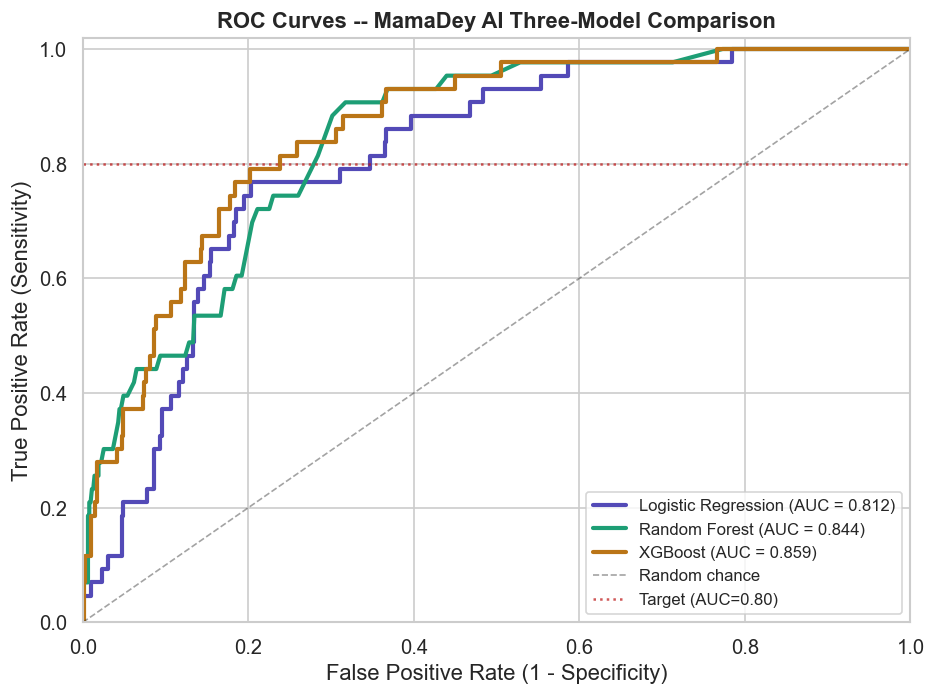

15:58:50 [INFO] Saved figure11_final_roc_comparison.png


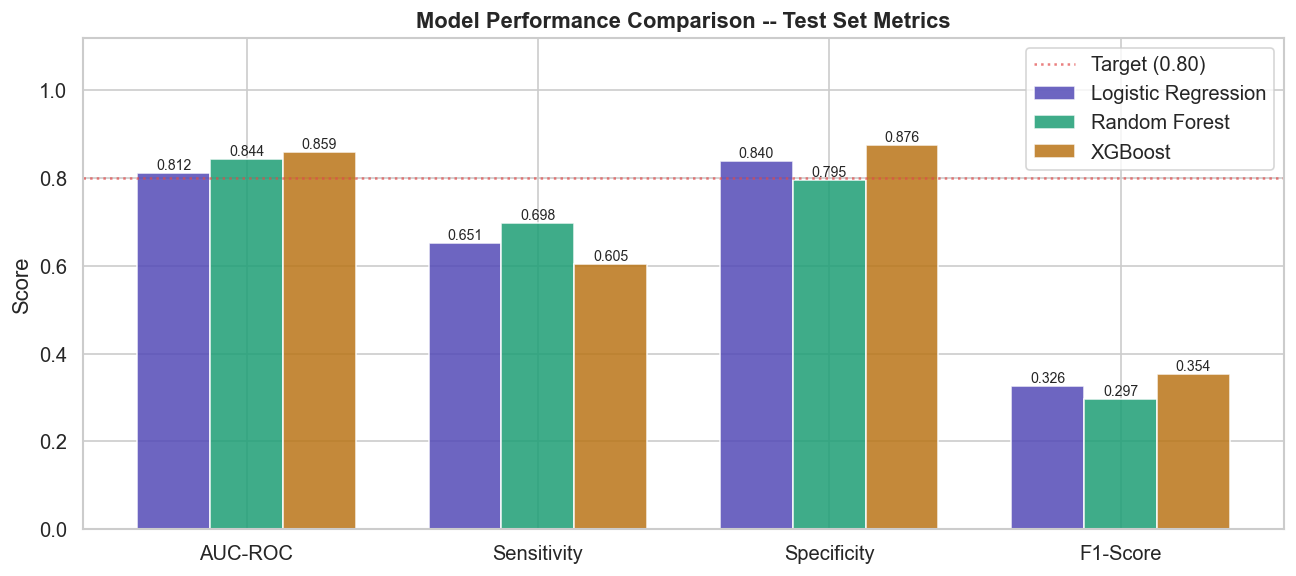

15:58:51 [INFO] Saved figure12_metrics_comparison.png


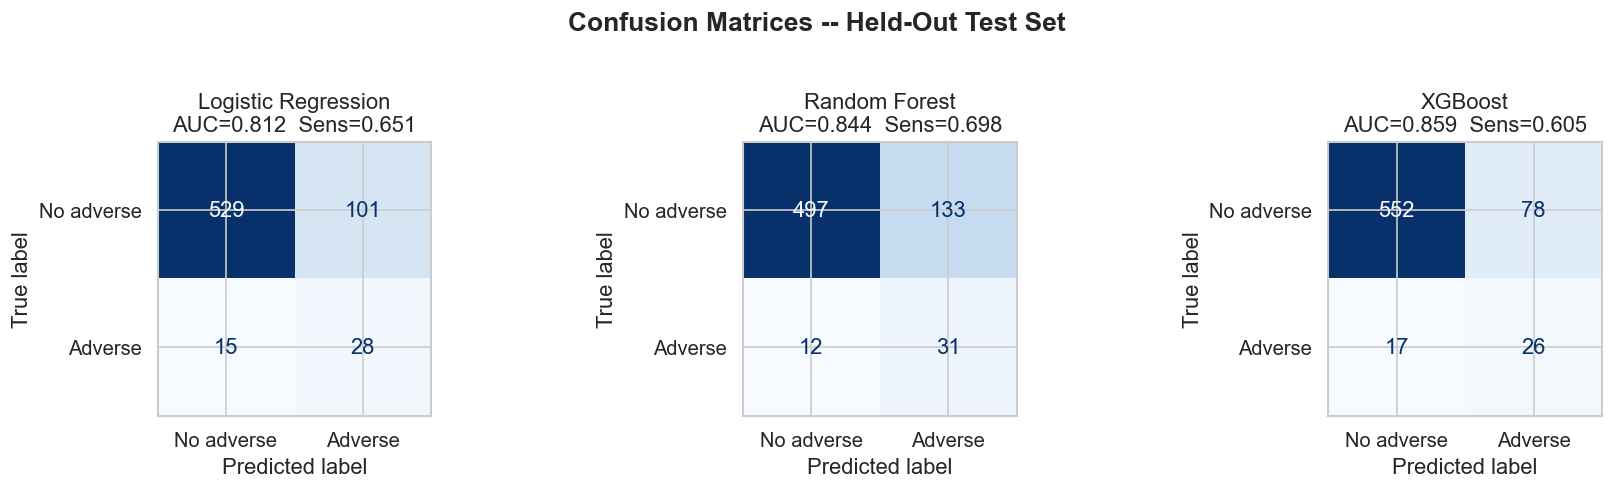

15:58:51 [INFO] Saved figure13_confusion_matrices.png


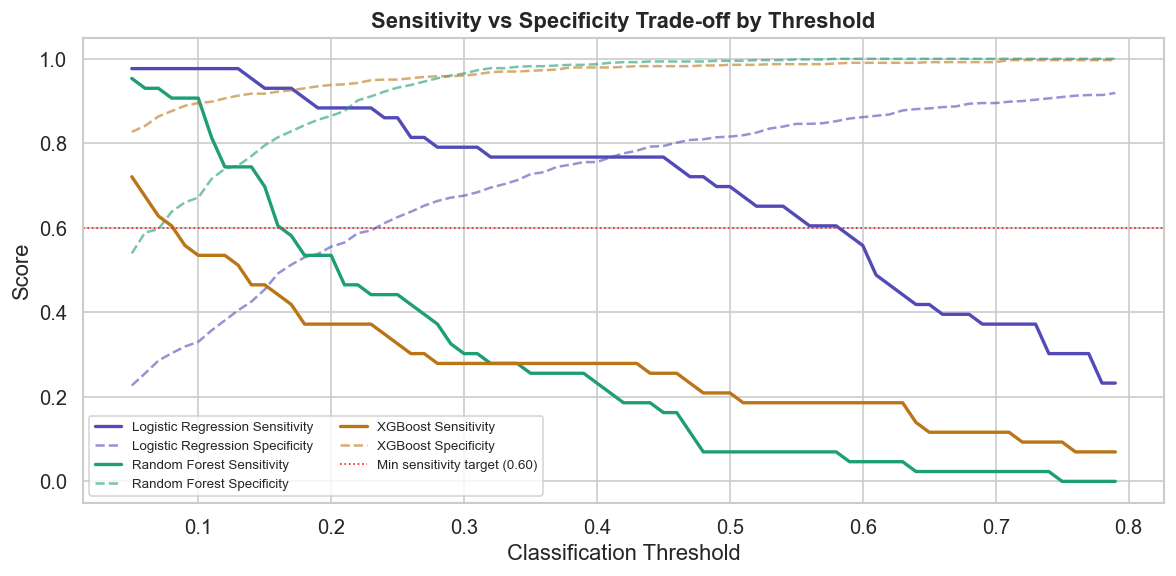

15:58:52 [INFO] Saved figure14_threshold_tradeoff.png
15:58:52 [INFO] Final report saved -> ../outputs/final_evaluation_report.csv



----------------------------------------------------------------------
FINAL MODEL COMPARISON (HELD-OUT TEST SET)
----------------------------------------------------------------------
                     AUC-ROC  Sensitivity  Specificity  Precision  F1-Score  Brier Score CV AUC Mean  Threshold
Model                                                                                                          
Logistic Regression   0.8120       0.6512       0.8397     0.2171    0.3256       0.1443        None     0.5400
Random Forest         0.8444       0.6977       0.7952     0.1887    0.2970       0.0521        None     0.1500
XGBoost               0.8586       0.6047       0.8762     0.2500    0.3537       0.0533        None     0.0800
----------------------------------------------------------------------

  ✓  Logistic Regression: AUC-ROC=0.8120  Sensitivity=0.6512
  ✓  Random Forest: AUC-ROC=0.8444  Sensitivity=0.6977
  ✓  XGBoost: AUC-ROC=0.8586  Sensitivity=0.6047


In [14]:
# Figures & comparison table
evaluator.plot_all()
final_table = evaluator.print_table()
evaluator.save_report(f"{output_dir}final_evaluation_report.csv")

15:59:05 [INFO] Computing SHAP values for Random Forest...


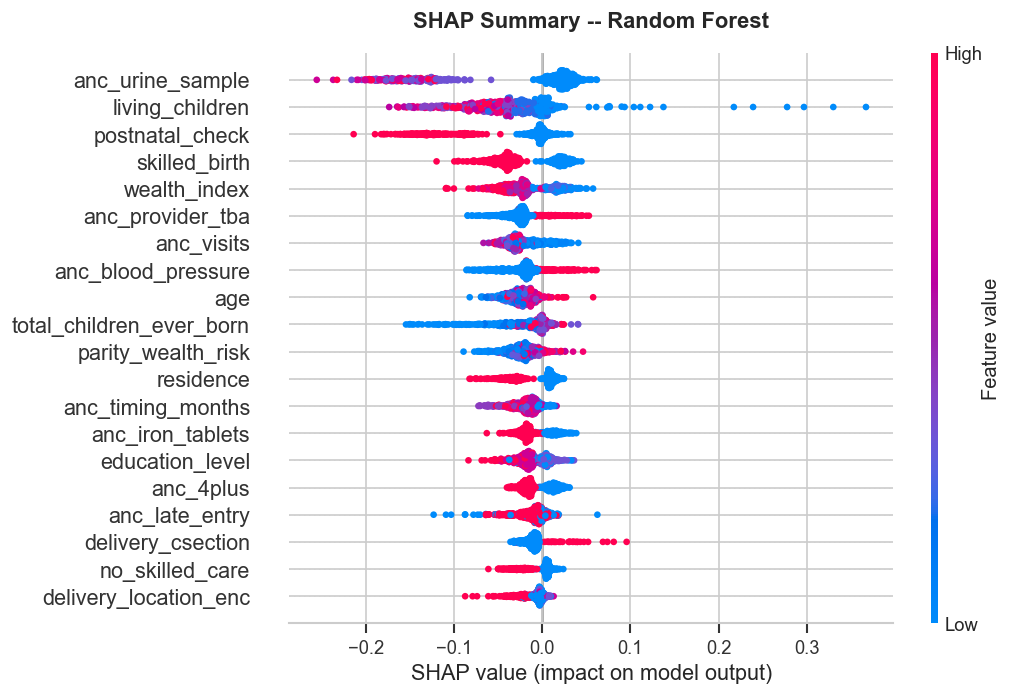

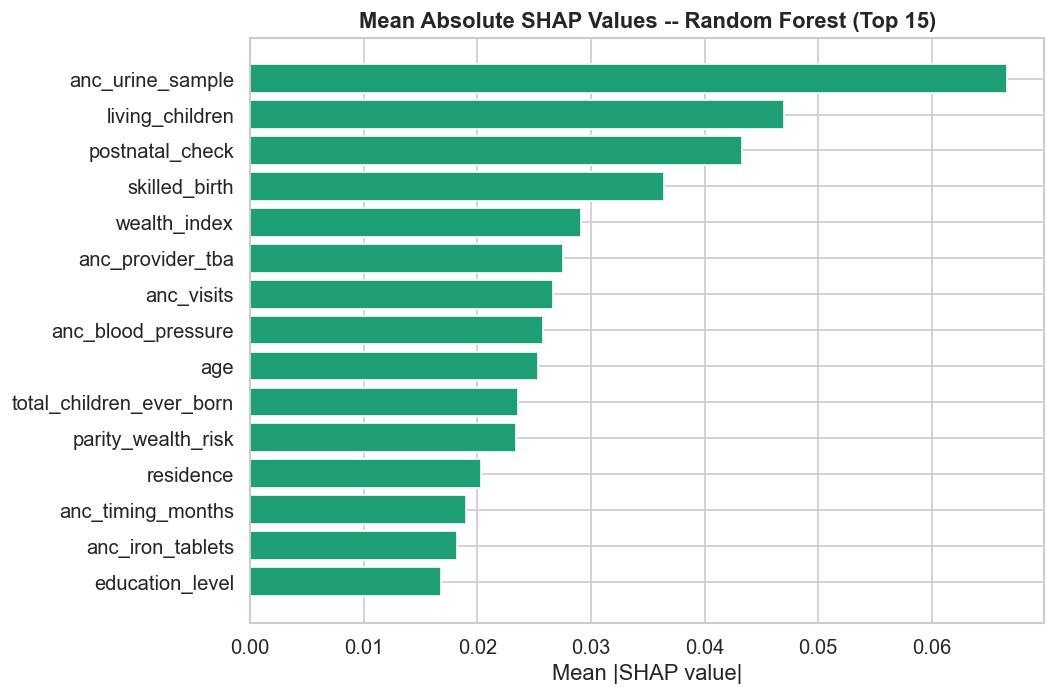

15:59:50 [INFO] SHAP analysis complete for Random Forest
15:59:50 [INFO] Computing SHAP values for XGBoost...


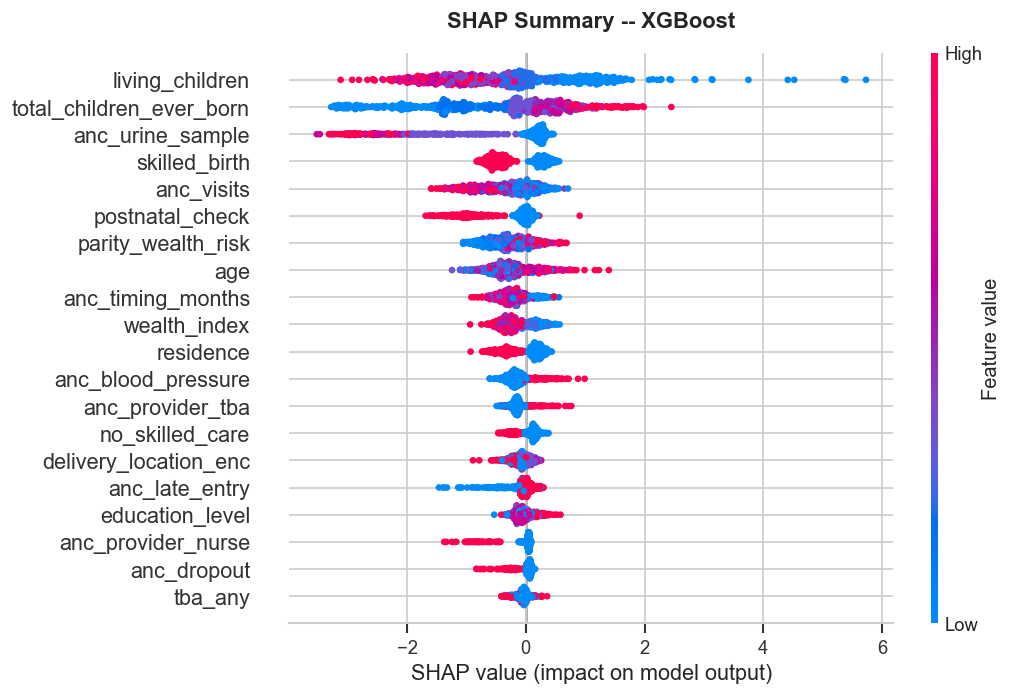

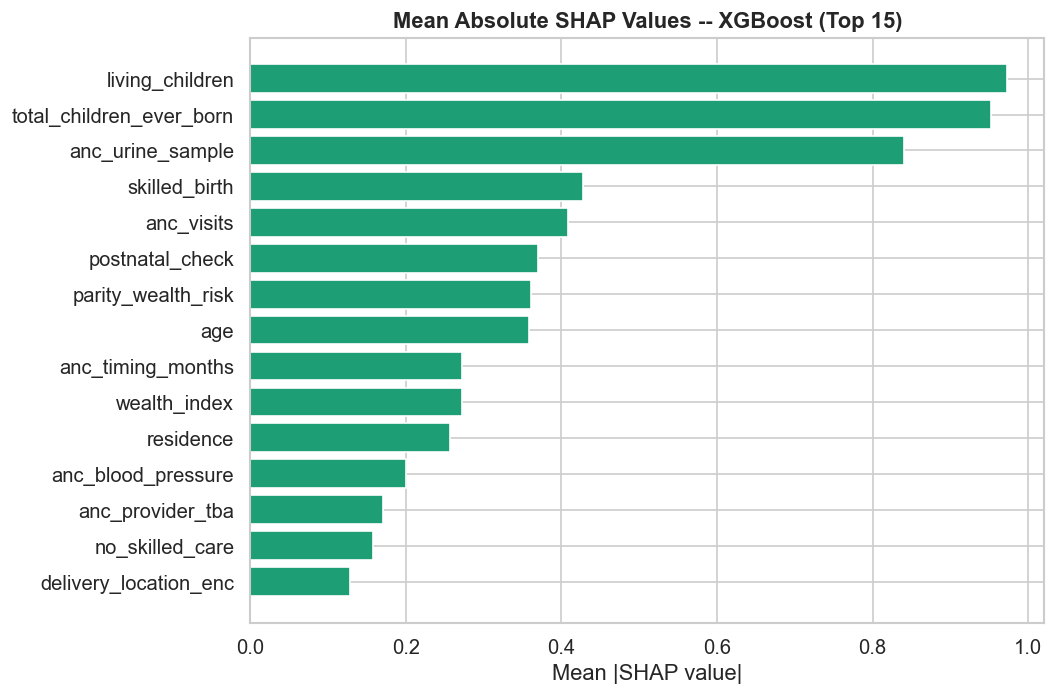

15:59:52 [INFO] SHAP analysis complete for XGBoost


,feature,mean_shap
23,delivery_location_enc,0.1285
27,no_skilled_care,0.1581
14,anc_provider_tba,0.1702
15,anc_blood_pressure,0.2008
0,residence,0.2564
3,wealth_index,0.2718
7,anc_timing_months,0.2725
1,age,0.3589
25,parity_wealth_risk,0.3612
22,postnatal_check,0.3705


In [15]:
# SHAP
shap_analyser = SHAPAnalyser(feature_columns, outputs_dir=output_dir)
shap_analyser.analyse("Random Forest", rf_model, X_test)
shap_analyser.analyse("XGBoost", xgb_trainer.model, X_test)

In [17]:
# Final model selection
candidates = {
    k: v for k, v in evaluator.results.items() if v["AUC-ROC"] >= 0.80
}
if not candidates:
    candidates = evaluator.results

best_model_name = max(
    candidates,
    key=lambda k: (
        candidates[k]["AUC-ROC"],
        candidates[k]["Sensitivity"],
        -candidates[k]["Brier Score"]
    )
)

model_objects = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_trainer.model
}
with open(f"{models_dir}best_model.pkl", "wb") as f:
    pickle.dump(model_objects[best_model_name], f)

best = evaluator.results[best_model_name]
print("=" * 60)
print(f"  Selected: {best_model_name}")
print(f"  AUC-ROC  : {best["AUC-ROC"]}")
print(f"  Sensitivity: {best["Sensitivity"]}")
print(f"  F1-Score : {best["F1-Score"]}")
print(f"  Brier    : {best["Brier Score"]}")
print("=" * 60)

meta = {"best_model": best_model_name,
        "auc_roc": best["AUC-ROC"],
        "sensitivity": best["Sensitivity"],
        "threshold": best["Threshold"]}
with open(f"{models_dir}best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
log.info(f"Best model: {best_model_name}")

16:02:55 [INFO] Best model: XGBoost


  Selected: XGBoost
  AUC-ROC  : 0.8586
  Sensitivity: 0.6047
  F1-Score : 0.3537
  Brier    : 0.0533


In [18]:
# Findings report
report_gen_4 = ReportGenerator_Week_8_10(
    evaluator       = evaluator,
    xgb_trainer     = xgb_trainer,
    best_model_name = best_model_name,
    y_test          = y_test,
    outputs_dir     = output_dir
)
metrics_w8_10 = report_gen_4.generate()

16:02:58 [INFO] Report saved -> ../outputs/report_week8_10.md


# MamaDey AI Findings Report (Week 8-10)
**Stage:** XGBoost Training, Three-Model Comparison, SHAP Interpretability
**Test set:** 673 records (43 adverse cases)

---

## 1. What Was Done

An XGBoost classifier was trained with GridSearchCV, comparing two class imbalance
strategies: SMOTE-balanced training data (consistent with the Random Forest approach)
and native scale_pos_weight handling on the original imbalanced data. The winning
strategy was SMOTE-balanced. All three models were evaluated on the held-out test
set using a clinically motivated threshold that enforces a minimum sensitivity of 0.60
before maximising F1. SHAP interpretability analysis was conducted on the two tree-based
models to identify the features driving predictions.

---

## 2. Key Findings

| Model               | AUC-ROC       | Sensitivity    | Specificity    | F1           | Brier           | Target              |
|---------------------|---------------|----------------|----------------|--------------|-------

### 8. Week 8-10 Checklist

In [20]:
xgb_auc = evaluator.results.get('XGBoost', {}).get('AUC-ROC', 0)
rf_auc  = evaluator.results.get('Random Forest', {}).get('AUC-ROC', 0)
lr_auc  = evaluator.results.get('Logistic Regression', {}).get('AUC-ROC', 0)

checks = {
    'XGBoost trained':                      xgb_trainer.model is not None,
    'Three-way evaluation complete':        len(evaluator.results) == 3,
    f'LR AUC-ROC = {lr_auc:.4f}':          lr_auc > 0,
    f'RF AUC-ROC = {rf_auc:.4f}':          rf_auc > 0,
    f'XGB AUC-ROC = {xgb_auc:.4f}':        xgb_auc > 0,
    'At least one model meets 0.80':        any(
        v['AUC-ROC'] >= 0.80 for v in evaluator.results.values()),
    'ROC comparison saved':                 os.path.exists(
        f'{output_dir}figure11_final_roc_comparison.png'),
    'Metrics comparison saved':             os.path.exists(
        f'{output_dir}figure12_metrics_comparison.png'),
    'Confusion matrices saved':             os.path.exists(
        f'{output_dir}figure13_confusion_matrices.png'),
    'Threshold trade-off saved':            os.path.exists(
        f'{output_dir}figure14_threshold_tradeoff.png'),
    'Final evaluation CSV saved':           os.path.exists(
        f'{output_dir}final_evaluation_report.csv'),
    'Best model saved':                     os.path.exists(
        f'{models_dir}best_model.pkl'),
    'Week 8-10 report saved':                  os.path.exists(
        f'{output_dir}report_week8_10.md'),
}

print('=' * 50)
print('WEEK (8-10) COMPLETION CHECKLIST')
print('=' * 50)
all_pass = True
for label, status in checks.items():
    icon = chr(10003) if status else chr(10007)
    print(f'  {icon}  {label}')
    if not status: all_pass = False
print('=' * 50)
if all_pass:
    print()
    print('All checks passed. Modelling complete.')
    print('All outputs ready for dissertation chapters 5 and 6.')
    print()
    print('Figures saved:')
    figs = sorted([f for f in os.listdir(output_dir) if f.endswith('.png')])
    for fig in figs:
        print(f'    {fig}')
else:
    print('Some checks failed -- review output above.')

WEEK (8-10) COMPLETION CHECKLIST
  ✓  XGBoost trained
  ✓  Three-way evaluation complete
  ✓  LR AUC-ROC = 0.8120
  ✓  RF AUC-ROC = 0.8444
  ✓  XGB AUC-ROC = 0.8586
  ✓  At least one model meets 0.80
  ✓  ROC comparison saved
  ✓  Metrics comparison saved
  ✓  Confusion matrices saved
  ✓  Threshold trade-off saved
  ✓  Final evaluation CSV saved
  ✓  Best model saved
  ✓  Week 8-10 report saved

All checks passed. Modelling complete.
All outputs ready for dissertation chapters 5 and 6.

Figures saved:
    fig_shap_bar_random_forest.png
    fig_shap_bar_xgboost.png
    fig_shap_summary_random_forest.png
    fig_shap_summary_xgboost.png
    figure10_feature_importance.png
    figure11_cv_distribution.png
    figure11_final_roc_comparison.png
    figure12_metrics_comparison.png
    figure13_confusion_matrices.png
    figure14_threshold_tradeoff.png
    figure1_anc_distribution.png
    figure2_delivery_location.png
    figure3_dropout_socioeconomic.png
    figure4_tba_involvement.png
    